In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [6]:
df=pd.read_csv("data/StudentsPerformance.csv")

In [7]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [9]:
#CHECK MISSING VALUES
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [10]:
#CHECK DUPLICATES
df.duplicated().sum()

np.int64(0)

In [11]:
#CHECK DATATYPE
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [12]:
#CHECK UNIQUE VALUES OF EACH COLUMN
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [13]:
#CHECK STATISTICS OF DATA SET
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [14]:
#CHECK VARUOUS CATEGORIES PRESENT IN DIFFERENT CATEGORICAL COLUMNS
print("Categories in 'gender' variable: ",end=" " )
print(df['gender'].unique())

print("Categories in 'race/ethnicity' variable: ",end=" " )
print(df['race/ethnicity'].unique())

print("Categories in 'parental level of education' variable: ",end=" " )
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable: ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable: ",end=" " )
print(df['test preparation course'].unique())




Categories in 'gender' variable:  <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race/ethnicity' variable:  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental level of education' variable:  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable:  <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [15]:
numerical_features=[col for col in df.columns if df[col].dtype!='str']
categorical_features=[col for col in df.columns if df[col].dtype=='str']

print(numerical_features)
print(categorical_features)

['math score', 'reading score', 'writing score']
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [16]:
df["total score"]=df["math score"]+df["reading score"]+df["writing score"]
df["average"]=df["total score"]/3

In [17]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [23]:
reading_full=df[df["reading score"]==100]["average"].count()
writing_full=df[df["writing score"]==100]["average"].count()
math_full=df[df["math score"]==100]["average"].count()

print(f'Number of students with full marks in Math,Writing,Reading {math_full},{writing_full},{reading_full}')

Number of students with full marks in Math,Writing,Reading 7,14,17


<Axes: xlabel='average', ylabel='Count'>

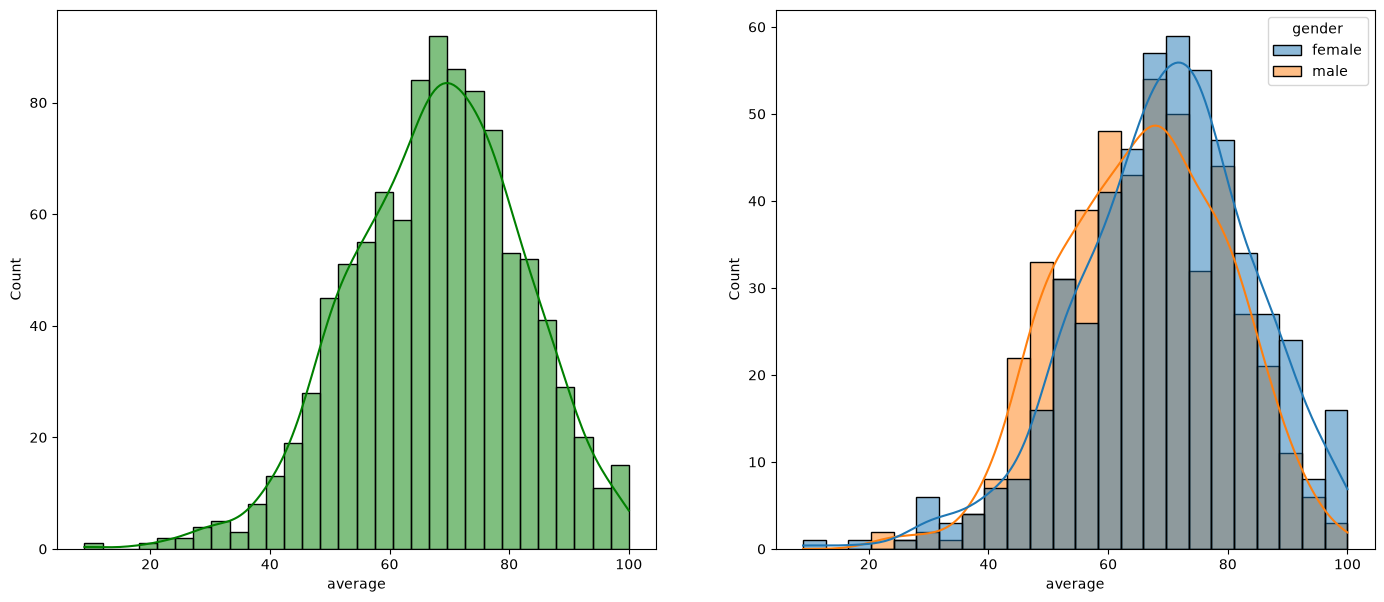

In [24]:
fig,axs=plt.subplots(1,2,figsize=(17,7))
plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average',kde=True,hue='gender')

<Axes: xlabel='average', ylabel='Count'>

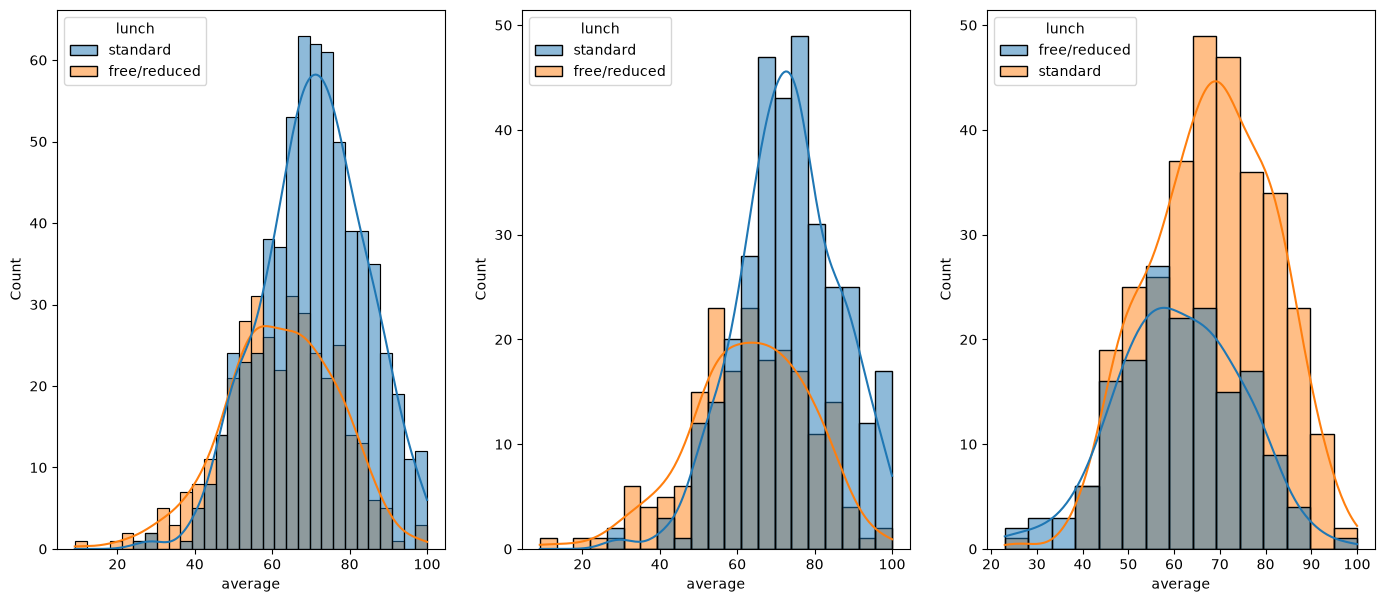

In [26]:
fig,axs=plt.subplots(1,3,figsize=(17,7))
plt.subplot(131)
sns.histplot(data=df,x='average',bins=30,kde=True,hue='lunch')
plt.subplot(132)
sns.histplot(data=df[df["gender"]=="female"],x='average',kde=True,hue='lunch')
plt.subplot(133)
sns.histplot(data=df[df["gender"]=="male"],x='average',kde=True,hue='lunch')

<Axes: xlabel='total score', ylabel='Count'>

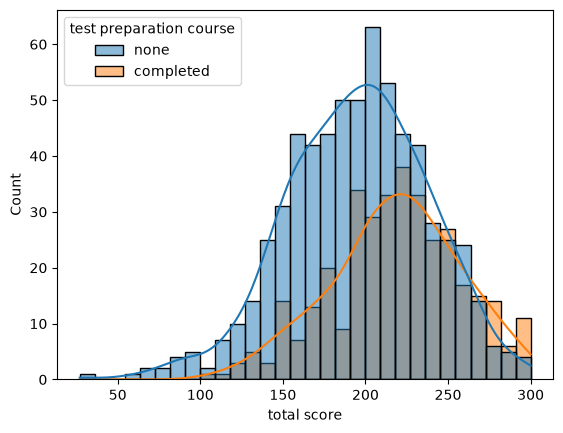

In [29]:
sns.histplot(data=df,x="total score",bins=30,kde=True,hue="test preparation course")

<Axes: xlabel='lunch', ylabel='count'>

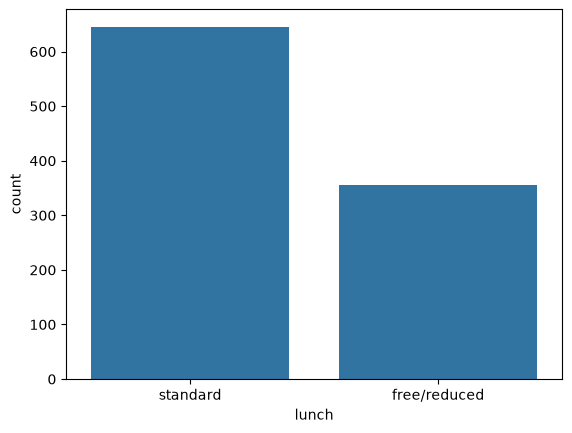

In [30]:
sns.countplot(x="lunch",data=df)

<Axes: xlabel='total score'>

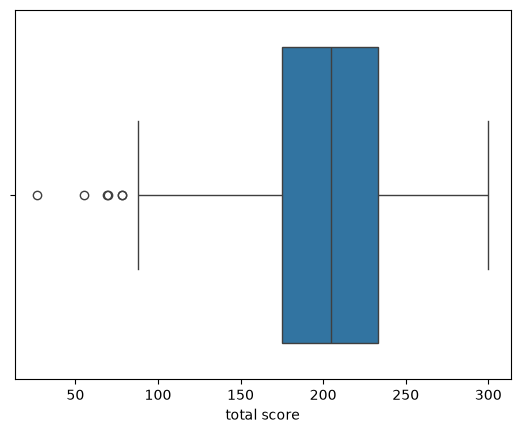

In [ ]:
sns.boxplot(data=df,x="")